# 01 - Simple Linear Regression applied to Real Estate 🏡 

___

<img src="https://marshfinancialadvice.com.au/wp-content/uploads/2018/10/mortgages_80.jpg" />

Photo by [Breno Assis](https://unsplash.com/@brenoassis)

___

In this exercice, you will be introduced to Machine Learning applied to continuous data various by playing with a small and simple dataset 🏡

We will study and fit a **linear regression**, which is the most straigthforward algorithm in regression, and we will discuss performance of the model.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Q1.** Load in a Pandas DataFrame the dataset `house_small.csv` located in `data/house_pricing` directory.

> ⚠️ **Warning**: In our file, values are separated by ";" this time - as opposed to "," as usual.

In [4]:
# TODO - Load data
from pathlib import Path

candidate_paths = [
    Path('data/house_pricing/house_small.csv'),
    Path('exercice3-dataset-house_small.csv'),
    Path('house_small.csv'),
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('house_small.csv not found in expected locations')

df = pd.read_csv(data_path, sep=';')
print(f'Loaded: {data_path} | shape = {df.shape}')
df.head()


Loaded: exercice3-dataset-house_small.csv | shape = (826, 3)


,price,surface,arrondissement
0,1827.0,44.1,1.0
1,1759.0,42.0,1.0
2,1903.0,54.0,1.0
3,1941.0,46.0,1.0
4,1950.0,48.0,1.0


**Q2.** Quickly explore the data
- How many data points does the dataset contain?
- How many features exist and which are they ?
- Describe briefly the data

In [5]:
# TODO - Get number of data points and number of features
n_points = len(df)
features = [col for col in df.columns if col != 'price']

print(f'Number of data points: {n_points}')
print(f'Number of features: {len(features)}')
print(f'Features: {features}')


Number of data points: 826
Number of features: 2
Features: ['surface', 'arrondissement']


In [6]:
# TODO - Describe data
df.describe(include='all')


,price,surface,arrondissement
count,825.000000,822.000000,822.000000
mean,2007.672727,58.106752,4.142336
std,1892.158336,44.886441,3.202151
min,395.000000,8.000000,1.000000
25%,1056.000000,28.625000,2.000000
50%,1570.000000,46.000000,3.000000
75%,2343.000000,72.460000,4.000000
max,25002.000000,412.000000,10.000000


**Q3.**
- Do you have any missing values? If yes, remove the associated rows.
- Visualize the data on a scatter plot. Is there any outlier(s)? If yes, remove them.
- Do you observe any correlation between variables? You can for example use the magic function `sns.pairplot` or also `pd.plotting.scatter_matrix(df)`

In [7]:
# TODO - Remove N/A
df_clean = df.dropna().copy()
print(f'Rows removed (missing values): {len(df) - len(df_clean)}')
print(df_clean.isna().sum())


Rows removed (missing values): 4
price             0
surface           0
arrondissement    0
dtype: int64


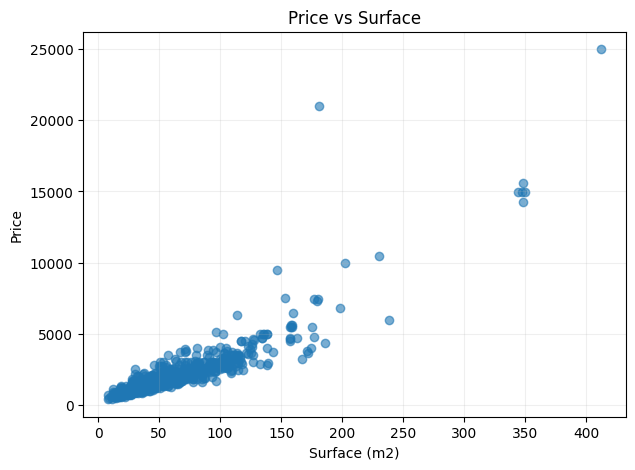

In [10]:
# TODO - Visualize the data
plt.figure(figsize=(7, 5))
plt.scatter(df_clean['surface'], df_clean['price'], alpha=0.6)
plt.title('Price vs Surface')
plt.xlabel('Surface (m2)')
plt.ylabel('Price')
plt.grid(alpha=0.2)
plt.show()


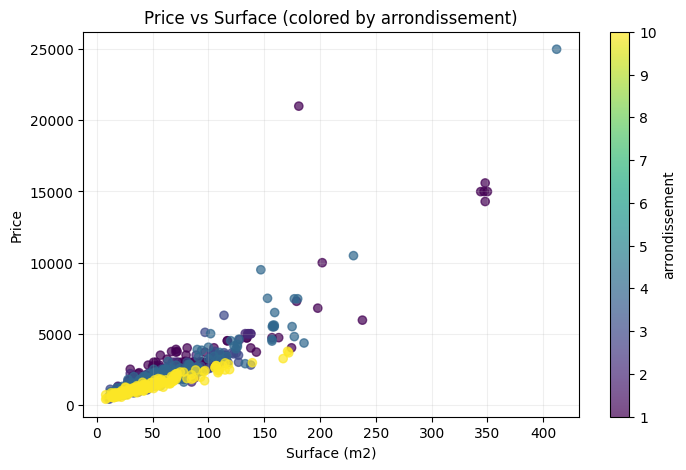

In [11]:
# TODO - Visualize the data
plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    df_clean['surface'],
    df_clean['price'],
    c=df_clean['arrondissement'],
    cmap='viridis',
    alpha=0.7
)
plt.title('Price vs Surface (colored by arrondissement)')
plt.xlabel('Surface (m2)')
plt.ylabel('Price')
plt.colorbar(scatter, label='arrondissement')
plt.grid(alpha=0.2)
plt.show()


In [12]:
# TODO - Remove outliers
cols = ['price', 'surface']
q1 = df_clean[cols].quantile(0.25)
q3 = df_clean[cols].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

mask = ((df_clean[cols] >= lower) & (df_clean[cols] <= upper)).all(axis=1)
df_model = df_clean[mask].copy()

print(f'Rows before outlier removal: {len(df_clean)}')
print(f'Rows after outlier removal:  {len(df_model)}')


Rows before outlier removal: 822
Rows after outlier removal:  772


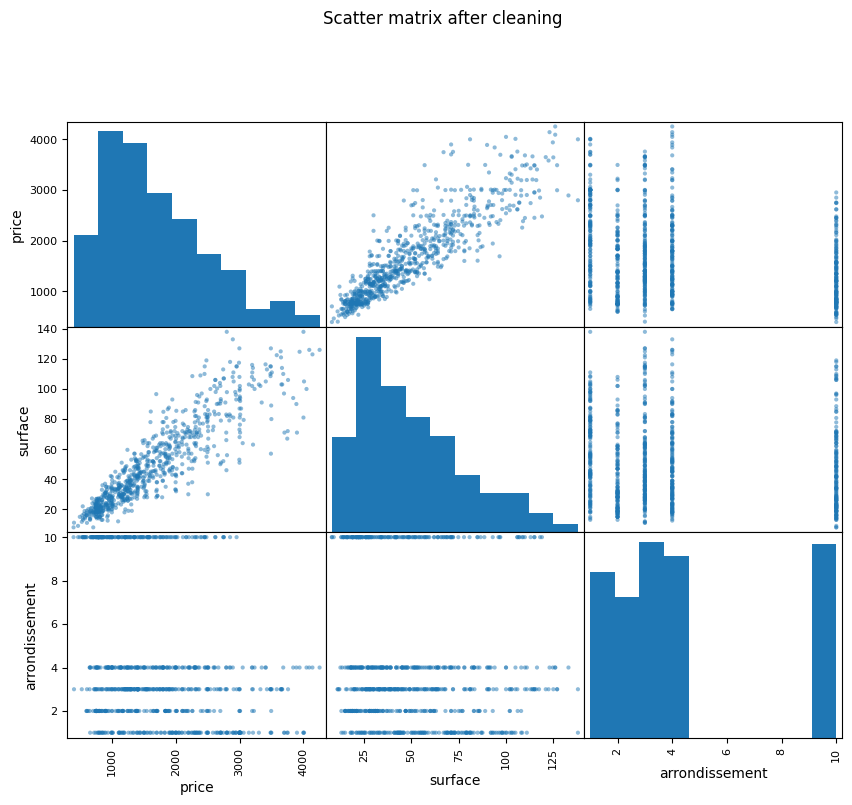

In [13]:
# TODO - Observe correlations between variables
pd.plotting.scatter_matrix(
    df_model[['price', 'surface', 'arrondissement']],
    figsize=(10, 8),
    diagonal='hist'
)
plt.suptitle('Scatter matrix after cleaning', y=1.02)
plt.show()


                   price   surface  arrondissement
price           1.000000  0.891607       -0.276315
surface         0.891607  1.000000       -0.105680
arrondissement -0.276315 -0.105680        1.000000


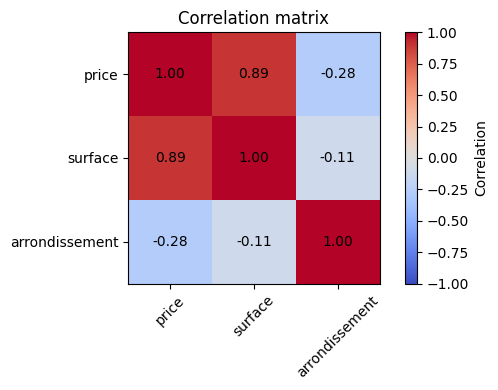

In [15]:
# TODO - Observe correlations between variables
corr = df_model.corr(numeric_only=True)
print(corr)

plt.figure(figsize=(6, 4))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center')
plt.title('Correlation matrix')
plt.colorbar(label='Correlation')
plt.tight_layout()
plt.show()


**Q4.** We are ready to apply our first **Machine Learning regression algorithm** 👊
- Thanks to `scikit-learn`, instanciate a **linear regression** and fit it to the cleaned dataset.
- Describe this Regression (and its coefficients) once trained
- Visualize results on a chart.

> 🔦 **Hint**: If you want to draw a line between 2 points `P1(x1, y1)` and `P2(x2, y2)` with matplotlib use : `plt.plot([x1, x2], [y1, y2]])`

In [16]:
# TODO - Fit a Linear Regression
from sklearn.linear_model import LinearRegression

X = df_model[['surface', 'arrondissement']]
y = df_model['price']

lr = LinearRegression()
lr.fit(X, y)
print('LinearRegression fitted')


LinearRegression fitted


In [17]:
# TODO - Describe the regression parameters
coef = pd.Series(lr.coef_, index=X.columns, name='coefficient')
print(f'Intercept: {lr.intercept_:.3f}')
coef


Intercept: 607.746


surface           25.225811
arrondissement   -46.154330
Name: coefficient, dtype: float64

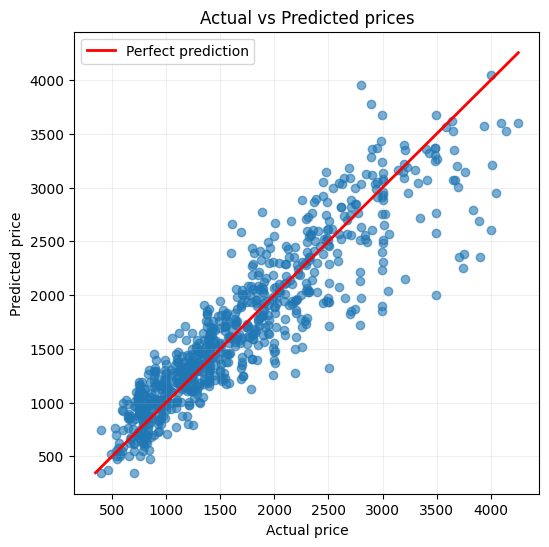

In [19]:
# TODO - Visualize results
y_pred = lr.predict(X)

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.6)
low = min(y.min(), y_pred.min())
high = max(y.max(), y_pred.max())
plt.plot([low, high], [low, high], color='red', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted prices')
plt.legend()
plt.grid(alpha=0.2)
plt.show()


**Q5.** What **score** (check in scikit-learn documentation the corresponding method) do you obtain for your linear regression? We will see later what this number corresponds to exactly 😉 

In [20]:
# TODO - Get correlation coefficient
r2 = lr.score(X, y)
print(f'R? score (train): {r2:.4f}')


R? score (train): 0.8285


**Q6.** I have a new house, of approximately 150 squared meters and located in district 19th. What price would you give to that new property? What if this new house is located in 1th district? 🤔

In [21]:
# TODO - Get a new prediction
new_houses = pd.DataFrame({
    'surface': [150, 150],
    'arrondissement': [19, 1]
})
new_houses['predicted_price'] = lr.predict(new_houses)
new_houses


,surface,arrondissement,predicted_price
0,150,19,3514.685875
1,150,1,4345.463823


TODO: Explanation
- For the same surface (150 m2), the model predicts a higher price in the 1st arrondissement than in the 19th.
- This is consistent with the learned coefficient for `arrondissement` (negative in this dataset).
- Prediction for arrondissement 19 is an extrapolation, since the dataset contains values from 1 to 10 only.
